In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [5]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 825kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.88MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.96MB/s]

Training samples: 60000
Testing samples: 10000


In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Number of training batches:", len(train_loader))
print("Number of testing batches:", len(test_loader))

Number of training batches: 938
Number of testing batches: 157


In [7]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])
First 10 labels: tensor([4, 2, 1, 1, 2, 0, 7, 7, 0, 8])


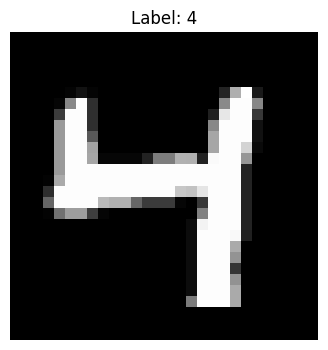

In [8]:
plt.figure(figsize=(4, 4))

plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")

plt.show()

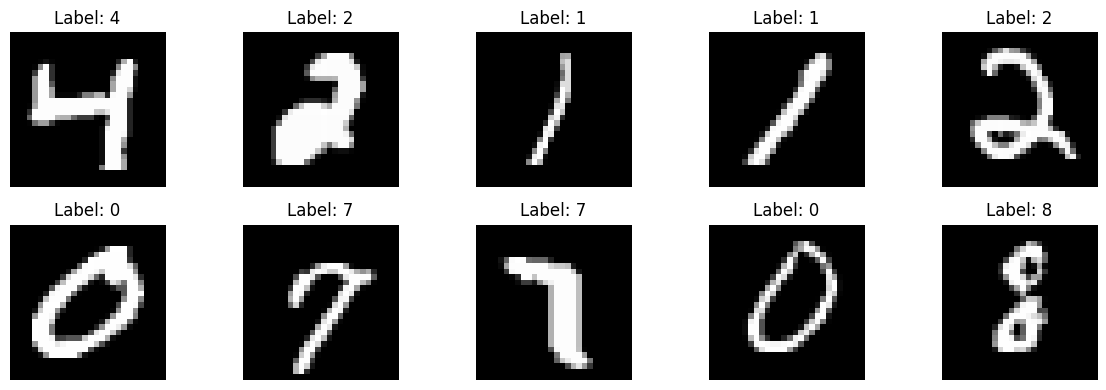

In [9]:
plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
print("Minimum pixel value:", images[0].min().item())
print("Maximum pixel value:", images[0].max().item())
print("Image shape:", images[0].shape)

Minimum pixel value: -1.0
Maximum pixel value: 1.0
Image shape: torch.Size([1, 28, 28])
